In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from graphufs.utils import cholesky_decomp

In [2]:
# set the file location and the name
HOME_DIR = "/global/homes/n/nagarwal"
file_loc = f"{HOME_DIR}/graph-ufs/prototypes/ocn_only/tendency_correlations"
corr_file_space = "tendency_correlation_ocn_only_24h_rm_seasonality_space_dependent.nc"
corr_file_global = "tendency_correlation_ocn_only_24h_rm_seasonality.nc"

In [6]:
# open file
ds_corr_space = xr.open_dataset(os.path.join(file_loc, corr_file_space))
ds_corr_global = xr.open_dataset(os.path.join(file_loc, corr_file_global))

In [7]:
ds_corr_space

<xarray.Dataset> Size: 248MB
Dimensions:     (channels_x: 29, lat: 192, lon: 384, channels_y: 29)
Coordinates:
  * channels_x  (channels_x) int64 232B 0 1 2 3 4 5 6 7 ... 22 23 24 25 26 27 28
  * lat         (lat) float64 2kB 89.82 88.89 87.95 ... -87.25 -88.18 -89.12
  * lon         (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * channels_y  (channels_y) int64 232B 0 1 2 3 4 5 6 7 ... 22 23 24 25 26 27 28
Data variables:
    targets     (lat, lon, channels_x, channels_y) float32 248MB ...

In [8]:
ds_corr_global

<xarray.Dataset> Size: 7kB
Dimensions:     (channels_x: 29, channels_y: 29)
Coordinates:
  * channels_x  (channels_x) int64 232B 0 1 2 3 4 5 6 7 ... 22 23 24 25 26 27 28
  * channels_y  (channels_y) int64 232B 0 1 2 3 4 5 6 7 ... 22 23 24 25 26 27 28
Data variables:
    targets     (channels_x, channels_y) float64 7kB ...

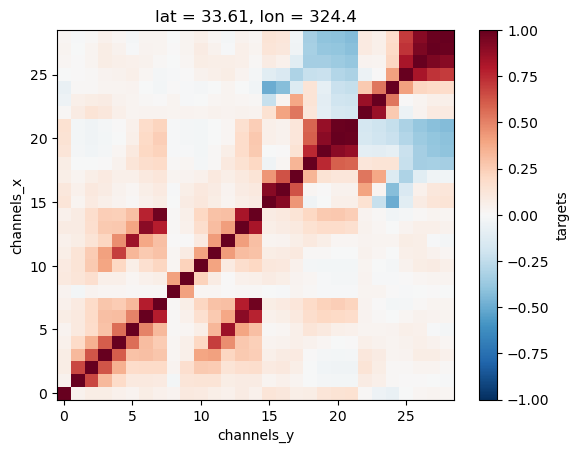

In [11]:
lat = 34 # Boulder: (40, -105); point in NA: (34, -36)
lon = -36 
lon_360 = (360 + lon) % 360
ds_corr_space.targets.sel(lat=lat, lon=lon_360, method='nearest').plot()
plt.show()

In [10]:
def safe_cholesky(matrix: np.ndarray) -> np.ndarray:
    """
    Safely computes the Cholesky decomposition.
    
    Checks for non-finite values (NaNs, Infs) first.
    If finite, it tries the decomposition. If it fails
    (not positive-definite), it also returns NaNs.
    """
    # Check for any NaNs or Infs
    # np.isfinite() is the fastest way to check for both.
    if not np.isfinite(matrix).all():
        # Return a NaN matrix of the same shape
        return np.full_like(matrix, np.nan)
        
    # If it's finite, try the decomposition
    try:
        return np.linalg.cholesky(matrix)
    
    # If it fails (LinAlgError), it's not positive definite
    except np.linalg.LinAlgError:
        # Return a NaN matrix
        return np.full_like(matrix, np.nan)

In [11]:
# Vectorized Cholesky Decomposition
def cholesky_decomp(cov_matrix: xr.DataArray) -> xr.DataArray:
    """
    Performs Cholesky decomposition on a stack of covariance matrices.

    Assumes the input DataArray has dimensions that define the stack
    (e.g., 'lat', 'lon') and the final two dimensions define the
    matrices to be decomposed (e.g., 'channels_x', 'channels_y').

    Args:
        cov_matrix (xr.DataArray): The stack of covariance matrices.

    Returns:
        xr.DataArray: The lower-triangular Cholesky factor (L)
                      for each matrix in the stack.
    """
    # Get the names of the last two dimensions (the matrix)
    matrix_dims = cov_matrix.dims[-2:]
    print("matrix dims:", matrix_dims)
    
    # Apply np.linalg.cholesky over the stack.
    # We tell apply_ufunc that the "core dimensions" for the
    # input and output are the two matrix dimensions.
    # It automatically loops over all other (e.g., 'lat', 'lon') dims.
    cholesky_L = xr.apply_ufunc(
        safe_cholesky,
        cov_matrix,
        input_core_dims=[matrix_dims],
        output_core_dims=[matrix_dims],
        dask="parallelized",  # Allows this to work with Dask arrays
        output_dtypes=[cov_matrix.dtype]
    )
    
    # The output L is lower-triangular
    cholesky_L.attrs['description'] = 'Lower-triangular Cholesky factor (L)'
    return cholesky_L

In [6]:
## --- Create the "Mask" using the finiteness of the matrix and its trace ---
# We need to diagnose the trace as well because several point near
# the continental shelf have zero values in the cross-channel correlation
# matrix for deeper level channels. This makes the corresponding matrix 
# symmetric positive semi-definite, not positive definite. But cholesky 
# decomposition requires SPD.

# 1. Compute the is_finite(lat, lon) mask to exclude any NaNs or Infs
da_corr = ds_corr.targets
is_finite_mask = da_corr.pipe(np.isfinite).all(dim=['channels_x', 'channels_y'])

# 2. Compute the "Trace Mask"
# We compute the trace for every matrix in the stack.
# np.einsum('...ii->...') is a fast, vectorized trace.
matrix_trace = xr.apply_ufunc(
    np.einsum, '...ii->...', da_corr,
    input_core_dims=[[], ['channels_x', 'channels_y']],
    output_core_dims=[[]], # Output is a lat/lon map
    dask='parallelized'
)
# Use np.isclose() for a robust float comparison to n_channels
n_channels = da_corr.sizes['channels_x']
trace_is_valid = np.isclose(matrix_trace, n_channels)
trace_is_valid_xr = xr.DataArray(trace_is_valid, dims=["lat","lon"], 
                               coords={"lat":da_corr["lat"].values, "lon":da_corr["lon"].values})

# 3. Compute the Final, Combined Mask
# A location is valid ONLY if it's 100% finite AND its trace is equal to n_channels.
valid_mask = is_finite_mask & trace_is_valid_xr
valid_mask.attrs['description'] = 'Locations where matrix is finite and positive-definite'

In [6]:
# --- Add a tiny jitter for Cholesky decomposition stability ---
# Add a small value to all diagonal elements for all lat/lon
# to stabilize the cholesky decomposition

# Create an identity matrix with the same channel dims
n_channels = ds_corr.sizes['channels_x']
channels = ds_corr["channels_x"].values
epsilon = 0  # 1e-6 is a common value

jitter = xr.DataArray(
    np.eye(n_channels) * epsilon,
    dims=['channels_x', 'channels_y'],
    coords={'channels_x': channels, 'channels_y': channels}
)

# Add the jitter the corr matrix. Xarray will broadcast it across lat/lon.
da_corr = ds_corr.targets
da_corr_stable = da_corr + jitter

In [7]:
# Now mask da_corr_stable
#da_corr_stable_masked = da_corr_stable.where(valid_mask)

## Check the Cholesky Decomposition

In [13]:
# Compute the Cholesky decomposition
L_cholesky_space = cholesky_decomp(ds_corr_space.targets)
L_cholesky_global = cholesky_decomp(ds_corr_global.targets)

Computing Cholesky decomposition over matrix dims: ('channels_x', 'channels_y')
Computing Cholesky decomposition over matrix dims: ('channels_x', 'channels_y')


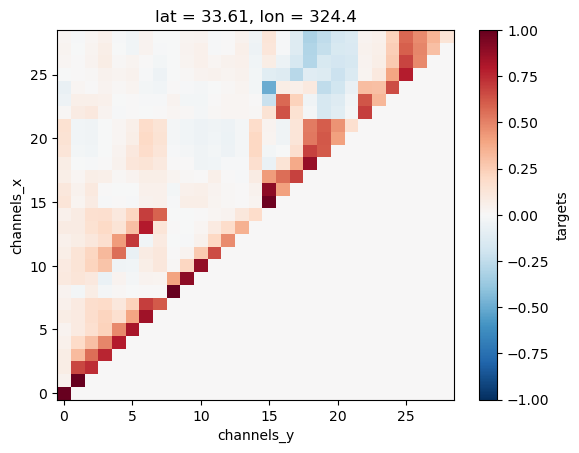

In [14]:
L_cholesky_space.sel(lat=lat, lon=lon_360, method='nearest').plot()
plt.show()

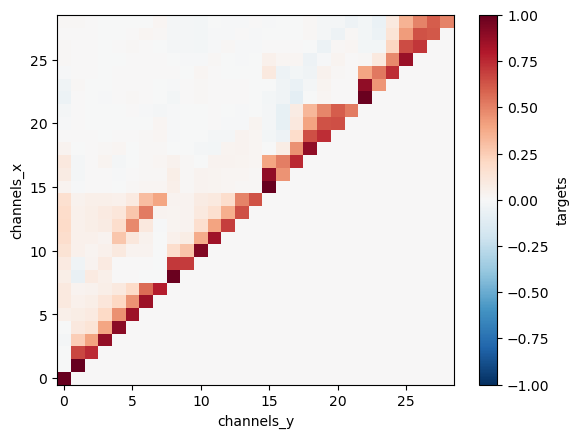

In [15]:
L_cholesky_global.plot()
plt.show()

## Inverse of Cholesky factor L

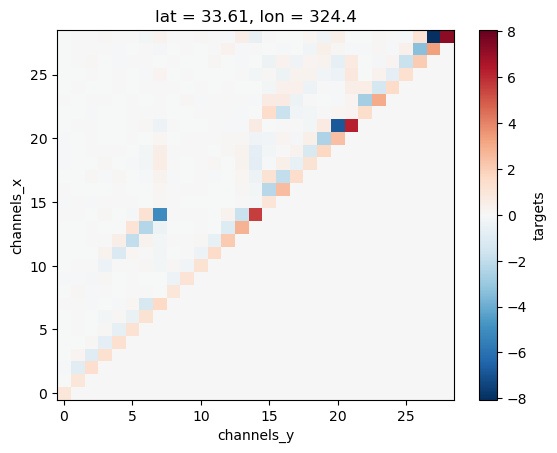

In [19]:
L_inv_space = np.linalg.inv(L_cholesky_space)
L_inv_space.sel(lat=lat, lon=lon_360, method='nearest').plot()
plt.show()

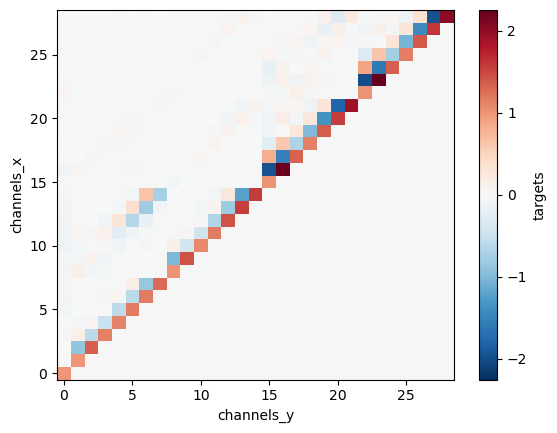

In [20]:
L_inv_global = np.linalg.inv(L_cholesky_global)
L_inv_global.plot()
plt.show()

## Max/Min values of Inverse L

In [25]:
print("max of L inverse global: ", L_inv_global.max().values)
print("max of L inverse space-dependent:", L_inv_space.max(skipna=True).values)

print("min of L inverse global: ", L_inv_global.min().values)
print("min of L inverse space-dependent:", L_inv_space.min(skipna=True).values)

max of L inverse global:  2.2531138574821137
max of L inverse space-dependent: 254.6880340576172
min of L inverse global:  -2.022832848251677
min of L inverse space-dependent: -271.2010803222656


In [77]:
# Get the lat/lon for which any entry in the inverse cholesky is greater than
# a threshold
L_inv_min_threshold = -50
L_inv_max_threshold = 50

# Now find all locations for which any of the channels x channels values for 
# the L_inv_space is greater than the threshold
greater_than_max = L_inv_space.max(dim=['channels_x', 'channels_y']) > L_inv_max_threshold
less_than_min = L_inv_space.min(dim=['channels_x', 'channels_y']) < L_inv_min_threshold

beyond_th_map = greater_than_max | less_than_min

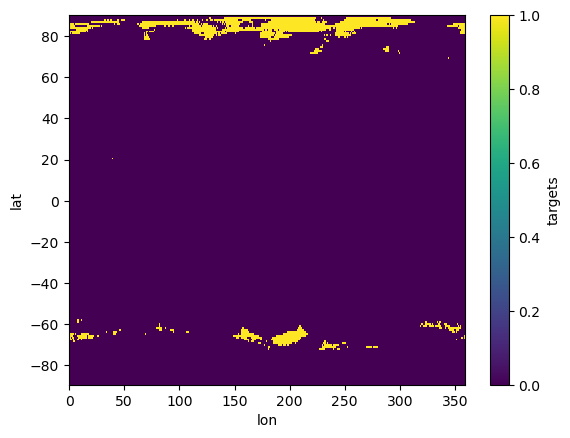

In [78]:
beyond_th_map.astype(int).plot()
plt.show()

In [52]:
da_stacked = da_thresholded.stack(points=('lat','lon'))
da_conditional = da_stacked.dropna(dim='points')
da_conditional.points.values

array([(89.82070742329198, 0.0), (89.82070742329198, 0.9375),
       (89.82070742329198, 1.875), ..., (-77.87892857194417, 321.5625),
       (-77.87892857194417, 322.5), (-77.87892857194417, 323.4375)],
      shape=(42548,), dtype=object)

In [53]:
da_conditional

<xarray.DataArray 'targets' (channels_x: 29, channels_y: 29, points: 42548)> Size: 143MB
array([[[ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00, ...,
          1.00000000e+00,  1.00000000e+00,  1.00000012e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

       [[ 2.21165363e-02,  2.26194784e-02,  2.30900906e-02, ...,
          1.18092634e-02,  1.94858555e-02,  2.73613837e-02],
        [ 1.00024462e+00,  1.00025582e+00,  1.00026655e+00, ...,
          1.00006974e+00,  1.00018978e+00,  1.00037432e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
...
         -2.52803707e+00, -2.58509350e+00, -3.67365098e+00],
        [ 6.88279390e+00,  6.92173862e+00,  6.95400763e+00, ...,
          2.42745185e+00,  2.49498749e+00,  3.38300920e+00],
        [-0.00000000e+00, -0.00000000e+00,  8.74973070e-16, ...,
         -0.00000000e+00, -0.00000000e+00, -0.00000000e+00]],

       [[-5.14332810e-03, -6.74929656e-03, -8.33814126e-03, ...,
         -1.41092101e-02, -3.95234162e-03, -2.42392123e-02],
        [ 1.71632245e-02,  1.43993786e-02,  1.16995303e-02, ...,
         -6.55790977e-03, -1.27977319e-02, -8.99367593e-03],
        [ 4.32771631e-02,  4.10151258e-02,  3.85330878e-02, ...,
         -5.96208870e-03,  1.04922932e-02, -2.83988025e-02],
        ...,
        [ 5.82781982e+00,  5.92121601e+00,  5.99321556e+00, ...,
          1.96128380e+00,  2.03466249e+00,  2.68468928e+00],
        [-1.58165102e+01, -1.59971924e+01, -1.61689720e+01, ...,
         -5.55896521e+00, -5.50274563e+00, -7.72938776e+00],
        [ 1.19043674e+01,  1.20202684e+01,  1.21406059e+01, ...,
          4.19155025e+00,  3.96418118e+00,  5.42393446e+00]]],
      shape=(29, 29, 42548), dtype=float32)
Coordinates:
  * channels_x  (channels_x) int64 232B 0 1 2 3 4 5 6 7 ... 22 23 24 25 26 27 28
  * channels_y  (channels_y) int64 232B 0 1 2 3 4 5 6 7 ... 22 23 24 25 26 27 28
  * points      (points) object 340kB MultiIndex
  * lat         (points) float64 340kB 89.82 89.82 89.82 ... -77.88 -77.88
  * lon         (points) float64 340kB 0.0 0.9375 1.875 ... 321.6 322.5 323.4

## Debugging the failing cholesky decomposition even after masking

In [9]:
def find_all_eigenvalues(matrix_stack: xr.DataArray) -> xr.DataArray:
    """
    Computes all eigenvalues for each matrix in a stack.
    Assumes the last two dimensions are the matrix dimensions.
    """
    matrix_dims = matrix_stack.dims[-2:]
    
    # Get the number of channels to create the new dimension
    n_channels = matrix_stack.sizes[matrix_dims[0]]
    eig_dim = "eigenvalue_idx" # Name for the new dimension
    
    # Apply np.linalg.eigvalsh.
    # The output is a new 1D core dimension.
    all_eigs = xr.apply_ufunc(
        np.linalg.eigvalsh,
        matrix_stack,
        input_core_dims=[matrix_dims],
        output_core_dims=[[eig_dim]], # Output is a new 1D array
        output_sizes={eig_dim: n_channels}, # We must tell xarray what the new dimension's coords are
        dask="parallelized",
        output_dtypes=[matrix_stack.dtype],
    )
    
    # Give the new coordinate a simple 0..N index
    all_eigs[eig_dim] = np.arange(n_channels)
    
    return all_eigs

In [10]:
# Apply to da_corr_stable after replacing nans with epsilon
da_corr_stable_debug = da_corr_stable.fillna(epsilon)
all_eigvals_map = find_all_eigenvalues(da_corr_stable_debug)

/tmp/ipykernel_982446/3462224684.py:14: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  all_eigs = xr.apply_ufunc(


In [11]:
# Find min eigenvalues map
min_eigvals_map = all_eigvals_map.min(dim='eigenvalue_idx')
min_eigvals_map.attrs['description'] = 'Minimum eigenvalue of the matrix'

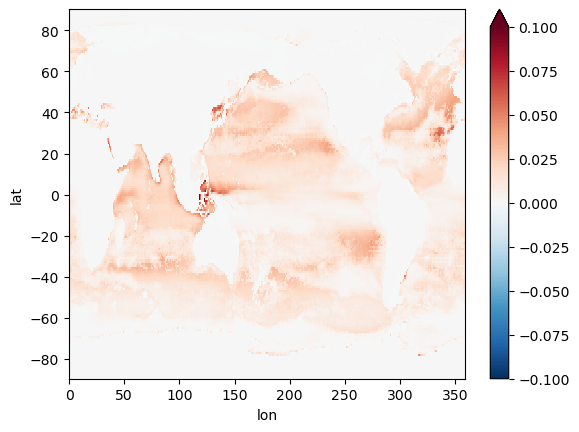

In [12]:
min_eigvals_map.plot(vmin=-0.1, vmax=0.1, cmap="RdBu_r")
plt.show()

Map of failing locations (1 = Bad):


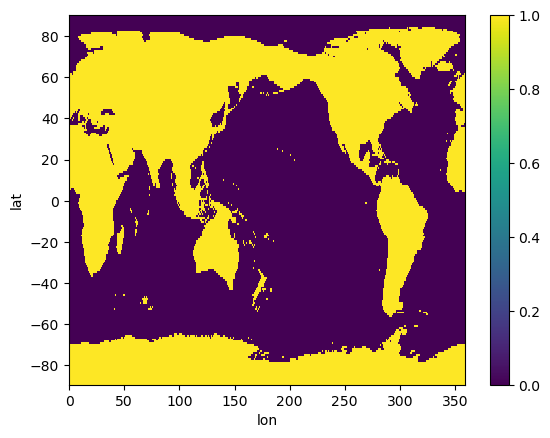

In [14]:
# Find the problematic locations 
problem_locations = xr.where(min_eigvals_map <= 0, 1, 0)

print("Map of failing locations (1 = Bad):")
problem_locations.plot()
plt.show()

In [15]:
# Take the difference of the above map from the land-sea mask diagnosed earlier
valid_mask_int = xr.where(valid_mask, 0, 1)
diff = valid_mask_int - problem_locations
diff.plot()
plt.show()

NameError: name 'valid_mask' is not defined

In [68]:
da_corr_stable_problematic = da_corr_stable.where(diff==1, drop=True)
da_corr_stable_problematic

<xarray.DataArray (lat: 76, lon: 124, channels_x: 29, channels_y: 29)> Size: 63MB
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
...
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]]], shape=(76, 124, 29, 29))
Coordinates:
  * channels_x  (channels_x) int64 232B 0 1 2 3 4 5 6 7 ... 22 23 24 25 26 27 28
  * lat         (lat) float64 608B 84.2 83.27 82.33 ... -75.07 -76.01 -76.94
  * lon         (lon) float64 992B 7.5 9.375 10.31 13.12 ... 351.6 352.5 359.1
  * channels_y  (channels_y) int64 232B 0 1 2 3 4 5 6 7 ... 22 23 24 25 26 27 28

In [74]:
problematic_lat_lon = []
for latv in da_corr_stable_problematic.lat.values:
    for lonv in da_corr_stable_problematic.lon.values:
        if da_corr_stable_problematic.sel(lat=latv, lon=lonv).pipe(np.isfinite).any():
            print(latv, lonv)
            problematic_lat_lon.append((latv,lonv))

84.2028734081873 288.75
84.2028734081873 313.125
84.2028734081873 314.0625
84.2028734081873 315.9375
83.26600010003588 339.375
82.32912272045655 50.625
82.32912272045655 54.375
82.32912272045655 62.8125
82.32912272045655 260.625
81.39224259860468 100.3125
80.45536054189336 83.4375
79.51847706911302 33.75
79.51847706911302 57.1875
79.51847706911302 287.8125
78.58159252881543 29.0625
78.58159252881543 30.9375
78.58159252881543 53.4375
78.58159252881543 163.125
78.58159252881543 164.0625
78.58159252881543 240.9375
78.58159252881543 343.125
77.6447071638476 42.1875
77.6447071638476 72.1875
77.6447071638476 76.875
77.6447071638476 121.875
77.6447071638476 238.125
77.6447071638476 255.9375
77.6447071638476 345.0
77.6447071638476 349.6875
76.70782114859902 50.625
76.70782114859902 51.5625
76.70782114859902 351.5625
76.70782114859902 352.5
75.77093461153613 30.0
75.77093461153613 173.4375
75.77093461153613 174.375
75.77093461153613 348.75
74.8340476493855 26.25
74.8340476493855 189.375
74.8340

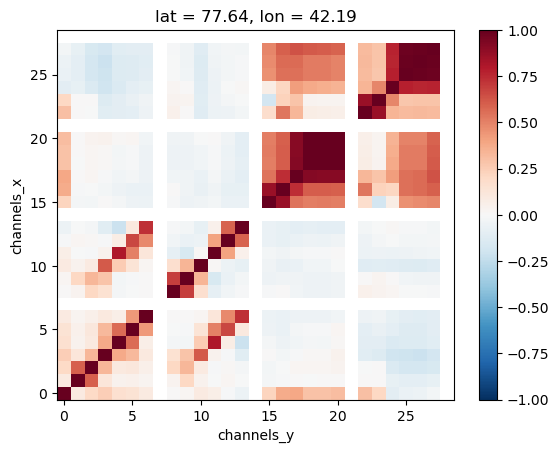

In [85]:
count = 21
problematic_crosscorr = da_corr_stable_problematic.sel(lat=problematic_lat_lon[count][0], 
                                                       lon=problematic_lat_lon[count][1])
problematic_crosscorr.plot()
plt.show()

In [14]:
test = np.linalg.cholesky(da_corr.sel(lat=0, lon=0, method="nearest"))
test

<xarray.DataArray 'targets' (channels_x: 29, channels_y: 29)> Size: 3kB
array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [-1.04156964e-01,  9.94560897e-01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
...
       [ 9.20733064e-02, -2.28150818e-03, -3.33535671e-02,
         6.01283042e-04, -6.41678646e-02,  4.34563756e-02,
         1.08796261e-01,  9.59081128e-02,  4.22044378e-03,
         2.96274219e-02,  2.74794200e-03, -4.86423671e-02,
        -2.36978475e-02,  1.97016820e-02,  6.75505251e-02,
        -2.56844331e-03, -2.20160782e-02, -2.41522659e-02,
         3.24450918e-02, -2.25283112e-02, -2.58338060e-02,
        -4.03519794e-02, -1.33044690e-01, -1.33919436e-02,
         2.43989959e-01,  5.25830507e-01,  4.48256254e-01,
         6.28337562e-01,  0.00000000e+00],
       [ 3.59899066e-02,  2.97009628e-02, -1.54358312e-03,
         2.61525833e-03, -6.39971718e-02, -1.80304758e-02,
        -1.44526111e-02,  1.00703239e-01, -5.76718003e-02,
        -2.31756568e-02,  5.06322226e-03, -5.47316559e-02,
        -1.98972095e-02, -5.34237809e-02,  5.40878177e-02,
         5.51273581e-03, -3.01852487e-02, -1.47366580e-02,
         6.11915737e-02,  7.30147399e-03, -5.36151044e-03,
        -4.42212783e-02, -2.14717746e-01, -4.46987189e-02,
        -4.35317941e-02,  1.18898988e-01,  1.44771650e-01,
         6.81866527e-01,  6.42656684e-01]], dtype=float32)
Coordinates:
  * channels_x  (channels_x) int64 232B 0 1 2 3 4 5 6 7 ... 22 23 24 25 26 27 28
    lat         float64 8B -0.1171
    lon         float64 8B 0.0
  * channels_y  (channels_y) int64 232B 0 1 2 3 4 5 6 7 ... 22 23 24 25 26 27 28

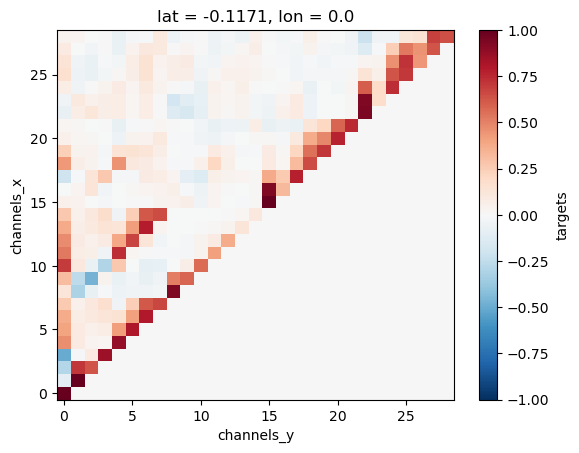

In [15]:
test.plot()
plt.show()

In [17]:
np.isfinite(da_corr.sel(lat=0, lon=0, method="nearest")).all()

<xarray.DataArray 'targets' ()> Size: 1B
array(True)
Coordinates:
    lat      float64 8B -0.1171
    lon      float64 8B 0.0